In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))
from mpc.configs import *
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from scipy.linalg import solve_discrete_are
import imageio
import torch
from stable_baselines3 import TD3



✓ Loaded 300k model


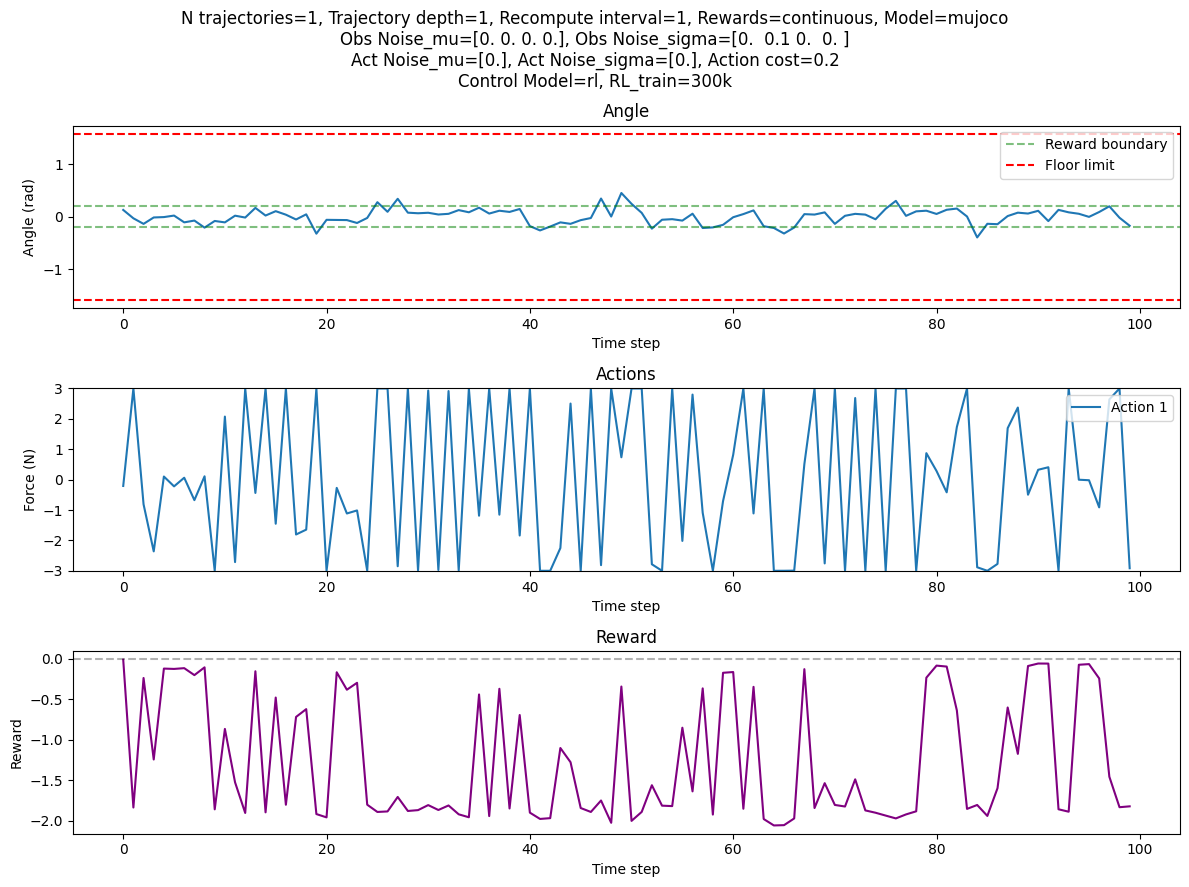

In [5]:
# Simulate the bird
planning_width = 1 # how many trajectories to simulate
n_planning = 1 # how deep the rolout of each trajectory is
recompute_interval = 1
n_episodes = 1 
time_steps = 100
reward_type='continuous' # rewards can be 'discrete' or 'continuous'
model_type='mujoco' # model can be 'mujoco' or 'linear_full' or 'linear_reduced_<int>' where <int> is the rank of the model
obs_noise_mu=np.array([0.0, 0.0, 0.0, 0.0]) # mean of the noise added to the observations
obs_noise_sigma=np.array([0.0, 0.1, 0.0, 0.0]) # standard deviation of the noise added to the observations
act_noise_mu=np.array([0.0]) # mean of the noise added to the actions
act_noise_sigma=np.array([0.0]) # standard deviation of the noise added to the actions
action_cost = 0.2
control_model = 'rl' # sampling method can be 'predictive' or 'random'
value = 'rl' # value can be 'env' or 'rl' to use MuJoCo env or RL model
rl_model = '300k' # name of the RL model to use, if applicable

bird = MPCShittyBird(n_actions = 10, planning_width=planning_width, n_planning=n_planning, reward_type=reward_type, model_type=model_type, action_cost=action_cost, control_model=control_model,value=value, rl_model=rl_model)

# Simulate the bird
simulation_data = simulate_one_model(bird, n_episodes=n_episodes, time_steps=time_steps,recompute_interval=recompute_interval, obs_noise_mu=obs_noise_mu, obs_noise_sigma=obs_noise_sigma, act_noise_mu=act_noise_mu, act_noise_sigma=act_noise_sigma, reward_type=reward_type, action_cost=action_cost)

episode1 = simulation_data["episode_1"]

angle = episode1["state_2"]

reward = episode1["reward"]

# Gather all action dimensions into a 2D array (time_steps, act_dim)
action_keys = sorted([k for k in episode1 if k.startswith("action_")])  # sorted for order
actions = np.vstack([episode1[k] for k in action_keys]).T

plt.figure(figsize=(12, 9))  # Made figure taller to accommodate third subplot
plt.suptitle(
    f'N trajectories={planning_width}, Trajectory depth={n_planning}, Recompute interval={recompute_interval}, Rewards={reward_type}, Model={model_type}\n'
    f'Obs Noise_mu={obs_noise_mu}, Obs Noise_sigma={obs_noise_sigma}\n'
    f'Act Noise_mu={act_noise_mu}, Act Noise_sigma={act_noise_sigma}, Action cost={action_cost}\n'
    f'Control Model={control_model}, RL_train={rl_model}',
    fontsize=12
)

# Plot the angle
plt.subplot(3, 1, 1)  # Changed to 3 rows
plt.plot(angle)
plt.title('Angle')
plt.xlabel('Time step')
plt.ylabel('Angle (rad)')
plt.axhline(y=-0.2, color='g', linestyle='--', alpha=0.5, label='Reward boundary')
plt.axhline(y=0.2, color='g', linestyle='--', alpha=0.5)
plt.axhline(y=-1.573, color='r', linestyle='--', label='Floor limit')
plt.axhline(y=1.573, color='r', linestyle='--')
plt.legend()

# Plot the actions
plt.subplot(3, 1, 2)  # Changed to 3 rows
plt.plot(actions)
plt.title('Actions')
plt.xlabel('Time step')
plt.ylabel('Force (N)')
plt.ylim(-3, 3)
plt.legend([f'Action {i+1}' for i in range(actions.shape[1])], loc='upper right')

# Add reward subplot
plt.subplot(3, 1, 3)
plt.plot(reward, 'purple')
plt.title('Reward')
plt.xlabel('Time step')
plt.ylabel('Reward')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()



In [48]:
single_sim_config = {
    'planning_width': 100,
    'reward_type': 'continuous',
    'model_type': 'mujoco',
    'obs_noise_mu': np.array([0.0, 0.0, 0.0, 0.0]),
    'obs_noise_sigma': np.array([0.0, 0.0, 0.0, 0.0]),
    'act_noise_mu': np.array([0.0]),
    'act_noise_sigma': np.array([0.0]),
    'n_episodes': 2,
    'time_steps': 100,
    'action_cost': 0.2,
    'control_model': 'predictive',
    'recompute_intervals': [1],         # Just one interval
    'n_planning_values': [1, 5, 10],            # Just one planning value
    'value': 'rl',
    'rl_model': '300k'  # Name of the RL model to use
}

run_simulations(single_sim_config)

Starting simulations with 1 intervals and 3 planning values
Running simulation with recompute_interval=1, n_planning=1
✓ Loaded 300k model
Model result saved to ..\results\models\model_interval1_planning1_obsnoise0.0_obsmu0.0_actnoise0.0_actmu0.0_time20250708-211404_modelpredictive_valuerl_rl_model300k.pkl
Running simulation with recompute_interval=1, n_planning=5
✓ Loaded 300k model
Model result saved to ..\results\models\model_interval1_planning5_obsnoise0.0_obsmu0.0_actnoise0.0_actmu0.0_time20250708-211404_modelpredictive_valuerl_rl_model300k.pkl
Running simulation with recompute_interval=1, n_planning=10
✓ Loaded 300k model
Model result saved to ..\results\models\model_interval1_planning10_obsnoise0.0_obsmu0.0_actnoise0.0_actmu0.0_time20250708-211404_modelpredictive_valuerl_rl_model300k.pkl
Simulations completed in 195.21 seconds


'20250708-211404'

Loaded model from ..\results\models\model_interval1_planning10_obsnoise0.0_obsmu0.0_actnoise0.0_actmu0.0_time20250708-190537_modelrl_valuerl_rl_model50k.pkl
Loaded model from ..\results\models\model_interval1_planning10_obsnoise0.0_obsmu0.0_actnoise0.0_actmu0.0_time20250708-191222_modelrl_valuerl_rl_model300k.pkl
Loaded model from ..\results\models\model_interval1_planning10_obsnoise0.4_obsmu0.0_actnoise0.0_actmu0.0_time20250708-185415_modelrl_valuerl_rl_model50k.pkl
Loaded model from ..\results\models\model_interval1_planning10_obsnoise0.4_obsmu0.0_actnoise0.0_actmu0.0_time20250708-192703_modelrl_valuerl_rl_model300k.pkl
Loaded model from ..\results\models\model_interval1_planning1_obsnoise0.0_obsmu0.0_actnoise0.0_actmu0.0_time20250708-190537_modelrl_valuerl_rl_model50k.pkl
Loaded model from ..\results\models\model_interval1_planning1_obsnoise0.0_obsmu0.0_actnoise0.0_actmu0.0_time20250708-191222_modelrl_valuerl_rl_model300k.pkl
Loaded model from ..\results\models\model_interval1_plann

(<Figure size 1400x600 with 2 Axes>,
 {1: {'n_planning': [1, 5, 10, 20, 30, 40],
   'means': [-1.1799192732366046,
    -0.8682140454102938,
    -0.8460532036921484,
    -0.7531881768694985,
    -1.0690327308928707,
    -0.9593092839414418],
   'std_errors': [0.06217236880093546,
    0.013518840629915596,
    0.17278181209877919,
    0.27915370380425364,
    0.05759687263507295,
    0.06310401726584802]}},
 {1: {'n_planning': [1, 5, 10, 20, 30, 40],
   'means': [37.0, 64.0, 64.0, 74.0, 44.5, 56.5],
   'std_errors': [5.999999999999999,
    1.0,
    16.0,
    25.999999999999996,
    3.4999999999999996,
    8.499999999999998]}})

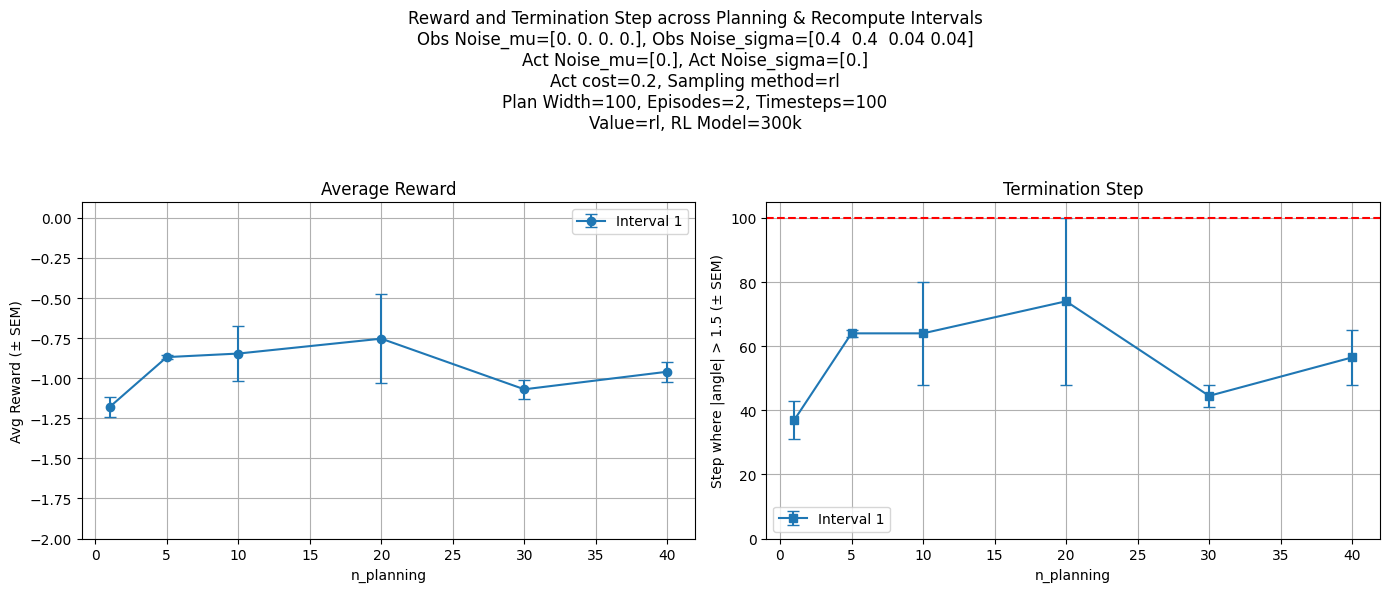

In [46]:
# Define configuration
obs_noise = 0.4

plot_config = {
    # 'planning_width': 200,
    # 'obs_noise_mu': np.array([0.0, 0.0, 0.00, 0.00]), 
    'obs_noise_sigma': np.array([obs_noise, obs_noise, round(obs_noise * 0.1, 2), round(obs_noise * 0.1, 2)]),
    # 'act_noise_mu': np.array([0.0]),
    # 'act_noise_sigma': np.array([0.0]),
    # 'obs_noise_sigma': np.array([0.4, 0.4, 0.04, 0.04]),
    'rl_model': '300k',  # Name of the RL model to use
    'control_model': 'rl',
}

analyze_and_plot_results(plot_config)

In [5]:
import os
import pickle
import numpy as np
import pandas as pd

def print_all_model_configs():
    """Print the configurations of all models in the models directory."""
    # Setup directory path
    results_dir = os.path.join('..', 'results')
    models_dir = os.path.join(results_dir, 'models')
    
    # Check if models directory exists
    if not os.path.exists(models_dir):
        print(f"Models directory not found: {models_dir}")
        return
    
    # Get all model files
    model_files = [f for f in os.listdir(models_dir) if f.endswith('.pkl')]
    
    if not model_files:
        print("No model files found in the models directory.")
        return
    
    print(f"Found {len(model_files)} model files.")
    
    # Create a list to store config data for DataFrame
    configs_data = []
    
    # Process each model file
    for model_file in model_files:
        file_path = os.path.join(models_dir, model_file)
        try:
            with open(file_path, 'rb') as f:
                model_data = pickle.load(f)
            
            if isinstance(model_data, dict) and 'config' in model_data:
                config = model_data['config']
                
                # Extract key parameters for the summary
                config_summary = {
                    'filename': model_file,
                    'interval': model_data.get('interval'),
                    'n_planning': model_data.get('n_planning'),
                    'obs_noise_mu': tuple(config.get('obs_noise_mu').tolist()) if isinstance(config.get('obs_noise_mu'), np.ndarray) else config.get('obs_noise_mu'),
                    'obs_noise_sigma': tuple(config.get('obs_noise_sigma').tolist()) if isinstance(config.get('obs_noise_sigma'), np.ndarray) else config.get('obs_noise_sigma'),
                    'act_noise_mu': tuple(config.get('act_noise_mu').tolist()) if isinstance(config.get('act_noise_mu'), np.ndarray) else config.get('act_noise_mu'),
                    'act_noise_sigma': tuple(config.get('act_noise_sigma').tolist()) if isinstance(config.get('act_noise_sigma'), np.ndarray) else config.get('act_noise_sigma'),
                    'planning_width': config.get('planning_width'),
                    'episodes': config.get('n_episodes'),
                    'time_steps': config.get('time_steps'),
                }
                
                configs_data.append(config_summary)
            else:
                print(f"Model file {model_file} doesn't have expected format")
                
        except Exception as e:
            print(f"Error loading {model_file}: {e}")
    
    # Create DataFrame for easy viewing and analysis
    if configs_data:
        df = pd.DataFrame(configs_data)
        
        # Print summary statistics
        print("\n--- Configuration Summary ---")
        print(f"Unique intervals: {sorted(df['interval'].unique())}")
        print(f"Unique planning horizons: {sorted(df['n_planning'].unique())}")
        print(f"Unique planning widths: {sorted(df['planning_width'].unique())}")
        print(f"Unique episode counts: {sorted(df['episodes'].unique())}")
        print(f"Unique time step counts: {sorted(df['time_steps'].unique())}")
        
        # Count configurations
        print("\n--- Parameter Combinations ---")
        param_counts = {
            'obs_noise_mu (first value)': df['obs_noise_mu'].apply(lambda x: x[0]).value_counts().to_dict(),
            'obs_noise_sigma (first value)': df['obs_noise_sigma'].apply(lambda x: x[0]).value_counts().to_dict(),
            'act_noise_mu': df['act_noise_mu'].apply(lambda x: x[0]).value_counts().to_dict(),
            'act_noise_sigma': df['act_noise_sigma'].apply(lambda x: x[0]).value_counts().to_dict()
        }
        for param, counts in param_counts.items():
            print(f"{param}: {counts}")
        
        # Cross tabulation of interval and planning horizon
        print("\n--- Interval × Planning Horizon Combinations ---")
        cross_tab = pd.crosstab(df['interval'], df['n_planning'])
        print(cross_tab)
        
        # Print full dataframe for detailed examination
        print("\n--- All Model Configurations ---")
        pd.set_option('display.max_rows', 500)
        pd.set_option('display.max_columns', 500)
        pd.set_option('display.width', 1000)
        print(df)
        
        return df
    
    return None

if __name__ == "__main__":
    print_all_model_configs()

Found 4 model files.

--- Configuration Summary ---
Unique intervals: [1]
Unique planning horizons: [1]
Unique planning widths: [2]
Unique episode counts: [2]
Unique time step counts: [5, 50]

--- Parameter Combinations ---
obs_noise_mu (first value): {0.0: 4}
obs_noise_sigma (first value): {0.0: 4}
act_noise_mu: {0.0: 4}
act_noise_sigma: {0.0: 4}

--- Interval × Planning Horizon Combinations ---
n_planning  1
interval     
1           4

--- All Model Configurations ---
                                            filename  interval  n_planning          obs_noise_mu       obs_noise_sigma act_noise_mu act_noise_sigma  planning_width  episodes  time_steps
0  model_interval1_planning1_obsnoise0.0_obsmu0.0...         1           1  (0.0, 0.0, 0.0, 0.0)  (0.0, 0.0, 0.0, 0.0)       (0.0,)          (0.0,)               2         2           5
1  model_interval1_planning1_obsnoise0.0_obsmu0.0...         1           1  (0.0, 0.0, 0.0, 0.0)  (0.0, 0.0, 0.0, 0.0)       (0.0,)          (0.0,)     